# 05_ml_pricing_basico.ipynb (v2)
**DyPriZa – Predicción de Precios (Linear vs Random Forest)**

Entrada: `data/DyPriZa_features.csv` (generado por 04_features v3)
Salidas:
- Métricas (MAE, RMSE, R²) por modelo
- `data/DyPriZa_predictions.csv` (test)
- `/mnt/data/DyPriZa_best_model.joblib` (modelo ganador por RMSE)


In [13]:

import numpy as np 
import pandas as pd 
from sklearn .model_selection import train_test_split 
from sklearn .preprocessing import StandardScaler 
from sklearn .pipeline import Pipeline 
from sklearn .linear_model import LinearRegression 
from sklearn .ensemble import RandomForestRegressor 
from sklearn .impute import SimpleImputer 


assert 'X'in globals ()and 'y'in globals (),"X e y no existen aún. Ejecuta la celda de preparación de datos."


X =X .replace ([np .inf ,-np .inf ],np .nan ).dropna (axis =1 ,how ='all')
mask =y .notna ()
X ,y =X .loc [mask ],y .loc [mask ]


if 'X_train'not in globals ()or 'X_test'not in globals ()or 'y_train'not in globals ()or 'y_test'not in globals ():
    X_train ,X_test ,y_train ,y_test =train_test_split (X ,y ,test_size =0.2 ,random_state =42 )
    print ("✅ Train/Test creado:",X_train .shape ,X_test .shape )


if 'models'not in globals ():
    num_imputer =SimpleImputer (strategy ='median')

    linear_pipe =Pipeline ([
    ('imputer',num_imputer ),
    ('scaler',StandardScaler (with_mean =False )),
    ('model',LinearRegression ())
    ])

    rf_pipe =Pipeline ([
    ('imputer',num_imputer ),
    ('model',RandomForestRegressor (n_estimators =300 ,random_state =42 ,n_jobs =-1 ))
    ])

    models ={
    'LinearRegression':linear_pipe ,
    'RandomForest':rf_pipe 
    }
    print ("✅ Modelos definidos: LinearRegression y RandomForest")


✅ Train/Test creado: (400, 19) (100, 19)


## 1) Detección robusta de columnas (target y opcionales de contexto)

In [15]:
import re 

cols_originales =list (data .columns )
lower_map ={c :c .lower ()for c in data .columns }
dfl =data .rename (columns =lower_map )

def detect_price_col (df ):
    cands =['precio','price','tarifa','adr','rate','avg_daily_rate','base_price']
    for c in df .columns :
        for k in cands :
            if k in c :
                return c 

    best_col ,score =None ,-1 
    for c in df .select_dtypes (include =[np .number ]).columns :
        s =pd .to_numeric (df [c ],errors ='coerce')
        sc =(s .notna ().mean ()*1000 )+s .var ()
        if s .max ()>0 and sc >score :
            best_col ,score =c ,sc 
    return best_col 

c_precio =detect_price_col (dfl )
c_fecha =next ((c for c in dfl .columns if c in ('fecha','date','ds')),None )
c_prop =next ((c for c in dfl .columns if c in ('propiedad','listing_id','property_id','id_propiedad','idpropiedad')),None )

assert c_precio is not None ,f"No se encontró la columna de precio. Columnas: {cols_originales}"
print ({'precio':c_precio ,'fecha':c_fecha ,'propiedad':c_prop })


y =pd .to_numeric (dfl [c_precio ],errors ='coerce')


drop_cols =[c for c in [c_precio ,c_fecha ,c_prop ]if c ]
X =dfl .drop (columns =drop_cols ,errors ='ignore').copy ()
X =X .select_dtypes (include =[np .number ])


mask =y .notna ()
X ,y =X .loc [mask ],y .loc [mask ]
print ('Variables X:',X .shape [1 ])


{'precio': 'adr', 'fecha': None, 'propiedad': None}
Variables X: 19


In [17]:


X =X .replace ([np .inf ,-np .inf ],np .nan )
X =X .dropna (axis =1 ,how ='all')
print ('Tras limpieza -> X shape:',X .shape )


Tras limpieza -> X shape: (500, 19)


## 2) Train/Test split y definición de modelos

In [19]:

from sklearn .impute import SimpleImputer 

num_imputer =SimpleImputer (strategy ='median')

linear_pipe =Pipeline ([
('imputer',num_imputer ),
('scaler',StandardScaler (with_mean =False )),
('model',LinearRegression ())
])

rf_pipe =Pipeline ([
('imputer',num_imputer ),
('model',RandomForestRegressor (n_estimators =300 ,random_state =42 ,n_jobs =-1 ))
])

models ={
'LinearRegression':linear_pipe ,
'RandomForest':rf_pipe 
}


## 3) Entrenamiento, evaluación y ranking por RMSE

In [21]:
def evaluate (y_true ,y_pred ):
    mae =mean_absolute_error (y_true ,y_pred )
    rmse =mean_squared_error (y_true ,y_pred ,squared =False )
    r2 =r2_score (y_true ,y_pred )
    return mae ,rmse ,r2 

rows =[]
preds_store ={}
for name ,pipe in models .items ():
    pipe .fit (X_train ,y_train )
    y_pred =pipe .predict (X_test )
    mae ,rmse ,r2 =evaluate (y_test ,y_pred )
    rows .append ({'Modelo':name ,'MAE':mae ,'RMSE':rmse ,'R2':r2 })
    preds_store [name ]=y_pred 
    print (f"{name} -> MAE={mae:.3f} | RMSE={rmse:.3f} | R2={r2:.3f}")

results_df =pd .DataFrame (rows ).sort_values ('RMSE',ascending =True ).reset_index (drop =True )
results_df 


C:\Users\nuria\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


LinearRegression -> MAE=1.854 | RMSE=2.660 | R2=0.996
RandomForest -> MAE=3.043 | RMSE=4.935 | R2=0.987


C:\Users\nuria\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


,Modelo,MAE,RMSE,R2
0,LinearRegression,1.853839,2.660235,0.996102
1,RandomForest,3.042779,4.934556,0.986588


## 4) Guardar mejor modelo y exportar predicciones de test

In [25]:

from pathlib import Path 
import joblib 
import pandas as pd 
import numpy as np 


PRED_PATH ='data/DyPriZa_predictions.csv'
Path ('data').mkdir (parents =True ,exist_ok =True )


MODEL_DIR =Path ('models')
MODEL_DIR .mkdir (parents =True ,exist_ok =True )
MODEL_PATH =MODEL_DIR /'DyPriZa_best_model.joblib'


best_name =results_df .iloc [0 ]['Modelo']
best_model =models [best_name ]


best_model .fit (X ,y )
joblib .dump (best_model ,MODEL_PATH )
print ('🏆 Mejor modelo:',best_name )
print ('💾 Guardado en:',MODEL_PATH )


best_model .fit (X_train ,y_train )
y_pred_best =best_model .predict (X_test )

pred_df =pd .DataFrame ({'precio_real':y_test .values ,'precio_predicho':y_pred_best })
pred_df ['error']=pred_df ['precio_real']-pred_df ['precio_predicho']


test_idx =X_test .index 
if 'fecha'in dfl .columns :
    pred_df ['fecha']=dfl .loc [test_idx ,'fecha']
if 'propiedad'in dfl .columns :
    pred_df ['propiedad']=dfl .loc [test_idx ,'propiedad']
elif 'listing_id'in dfl .columns :
    pred_df ['listing_id']=dfl .loc [test_idx ,'listing_id']
elif 'property_id'in dfl .columns :
    pred_df ['property_id']=dfl .loc [test_idx ,'property_id']

pred_df .to_csv (PRED_PATH ,index =False )
print ('✅ Predicciones guardadas en:',PRED_PATH )

pred_df .head (5 )



🏆 Mejor modelo: LinearRegression
💾 Guardado en: models\DyPriZa_best_model.joblib
✅ Predicciones guardadas en: data/DyPriZa_predictions.csv


,precio_real,precio_predicho,error
0,127.61,129.045936,-1.435936
1,171.36,169.842990,1.517010
2,110.36,113.344535,-2.984535
3,101.36,102.551963,-1.191963
4,148.69,147.455519,1.234481


## 5) Gráficos de validación (dispersión y residuales)

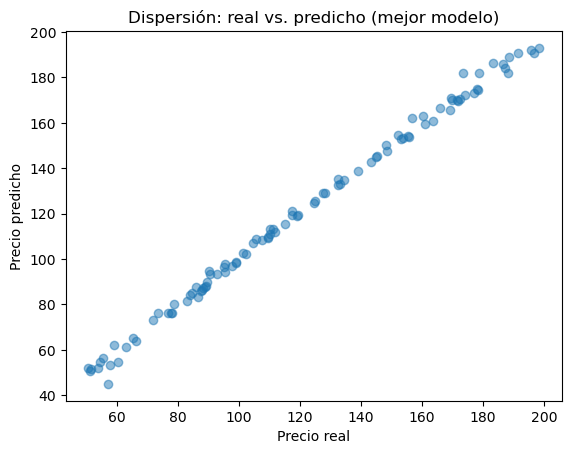

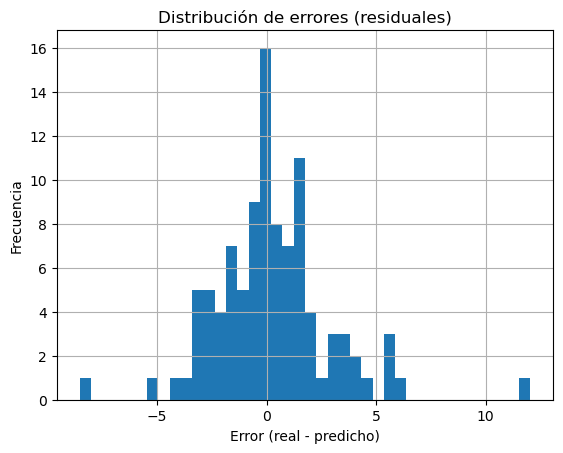

In [27]:
plt .figure ()
plt .scatter (pred_df ['precio_real'],pred_df ['precio_predicho'],alpha =0.5 )
plt .xlabel ('Precio real')
plt .ylabel ('Precio predicho')
plt .title ('Dispersión: real vs. predicho (mejor modelo)')
plt .show ()

plt .figure ()
pred_df ['error'].hist (bins =40 )
plt .xlabel ('Error (real - predicho)')
plt .ylabel ('Frecuencia')
plt .title ('Distribución de errores (residuales)')
plt .show ()

if 'fecha'in pred_df .columns :
    tmp =pred_df .sort_values ('fecha').copy ()
    plt .figure ()
    plt .plot (tmp ['fecha'],np .abs (tmp ['error']).values )
    plt .xlabel ('Fecha')
    plt .ylabel ('Error absoluto')
    plt .title ('Error absoluto a lo largo del tiempo')
    plt .xticks (rotation =45 )
    plt .tight_layout ()
    plt .show ()


In [29]:

print (results_df ,"\n")
best_name =results_df .iloc [0 ]['Modelo']
print ("🏆 Mejor modelo:",best_name )


row =results_df .iloc [0 ]
print (f"MAE={row['MAE']:.3f}  RMSE={row['RMSE']:.3f}  R2={row['R2']:.3f}")


             Modelo       MAE      RMSE        R2
0  LinearRegression  1.853839  2.660235  0.996102
1      RandomForest  3.042779  4.934556  0.986588 

🏆 Mejor modelo: LinearRegression
MAE=1.854  RMSE=2.660  R2=0.996
